In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
device = 'cuda:5'

In [4]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [6]:
cellstate_key = "DM_scaled"
n_dimension = 10
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [7]:
Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=9, 
                    n_dimension=10,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=True,
                    deltax_key=None,
                    batchsize= 100)

Computing density :
`density_funs` not specified, use gaussian kde


# load model

In [8]:
model_ckpt = "logs/tom_pos-DM_scaled_n9/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=257-total_loss=0.76506275.ckpt"
pde_model = models.pde_params.load_from_checkpoint(model_ckpt)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


<Axes: title={'center': 'anno_man'}, xlabel='UMAP1', ylabel='UMAP2'>

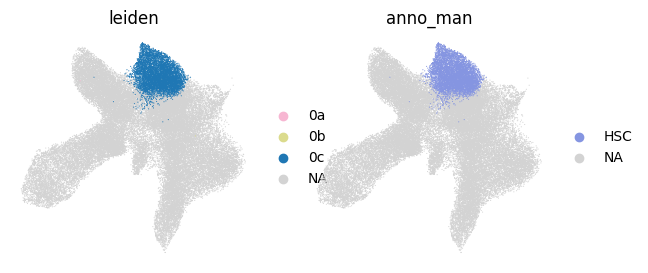

In [9]:
fig, axs = plt.subplots(1,2, figsize=(7,3))
sc.pl.umap(adata, color='leiden', groups=['0a', '0b', '0c'], ax=axs[0], show=False, frameon=False)
sc.pl.umap(adata, color='anno_man', groups='HSC', ax=axs[1], show=False, frameon=False)

# go for all HSC cells

In [10]:
n_interval = 10
ncell = 100

In [11]:
from torch import nn
import torch.nn.functional as F

In [12]:
pde_model = pde_model.to(device)

In [13]:
def velocity(t, s):
    t_in = torch.full((s.shape[0],1), t.item()).to(device)
    ds = pde_model.v(s, t_in*pde_model.time_scale_factor)
    return ds

def transition_by_batch(s0, u0, integrate_time):

    
    zeros = torch.zeros_like(u0)
    duds_init = torch.zeros_like(s0)

    with torch.no_grad():
        s_out = odeint(velocity, y0=s0, 
                    t=torch.tensor(integrate_time).to(device)*pde_model.time_scale_factor)

        s_traj_ay = s_out.detach().cpu().clone().numpy()


    intout  = odeint(
                    pde_model,
                    y0 = (u0, s0, duds_init, zeros, zeros, zeros),
                    t = torch.tensor(integrate_time).type(torch.float32).to(device),
                    atol=pde_model.ode_tol,
                    rtol=pde_model.ode_tol,
                    method='dopri5',
                )
    u_traj_ay = nn.functional.relu(intout[0]).detach().cpu().clone().numpy()
    del intout, s_out


    leftover_u_global = [ np.zeros((n_interval, u0.shape[0])) ]
    diff_flow_u_global = []

    with torch.set_grad_enabled(True):
        for offset in range(n_interval):


            s_traj = torch.from_numpy(s_traj_ay).float().to(device)
            
            tn1 = integrate_time[0]
            diff_flow_u_local = [u_traj_ay[offset]]
            leftover_u_local = []

            # pde_model = model_class.load_from_checkpoint(ckpt_path).eval().to(device)

            for i, t in enumerate(integrate_time[1:n_interval-offset+1]):
                
                # if i==0:
                #     t0 = torch.full((s_tn1[0].shape,1), tn1).requires_grad_().to(device).float()
                #     u0 = pde_model.get_u(s_tn1, t0)
                #     diff_flow_u.append(u0.detach())

                s_tn1 = s_traj[i].requires_grad_().to(device)
                s_t = s_traj[i+1].requires_grad_().to(device)
                
                left_u = torch.from_numpy(leftover_u_global[-1][i]).requires_grad_().to(device) # left from last round of diff trajactory
                inflow_u = torch.from_numpy(diff_flow_u_local[-1]).requires_grad_().to(device)  # inflow from last step of the same round of diff trajectory
                u_tn1 = left_u.float() + inflow_u.float()
                u_t = torch.zeros_like(u_tn1).to(device)

                # integrate the flow within small timespan
                s_last, u_stay, s_next, u_flow = odeint(pde_model.density_transfer, 
                                y0= (s_tn1, u_tn1, s_t, u_t), 
                                t = torch.tensor([tn1, t]).float().to(device),
                                rtol = pde_model.ode_tol,
                                atol = pde_model.ode_tol,
                                )
                
                diff_flow_u_local.append( F.relu(u_flow[-1].detach()).clone().cpu().numpy() )
                leftover_u_local.append( F.relu(u_stay[-1].detach()).clone().cpu().numpy() )
                tn1 = t

                del s_tn1, s_t, u_tn1, u_t, left_u, inflow_u, s_last, u_stay, s_next, u_flow
                torch.cuda.empty_cache()
                pde_model.zero_grad()

            diff_flow_u_local = np.stack(diff_flow_u_local)[1:] # length : 100 - offset
            leftover_u_local = np.stack(leftover_u_local)#[1:]   # length : 100 - offset - 1

            diff_flow_u_global.append(diff_flow_u_local)
            leftover_u_global.append(leftover_u_local)

            torch.cuda.empty_cache()

            del diff_flow_u_local, leftover_u_local,  s_traj #, pde_model
        
            # print(torch.cuda.memory_allocated() / 1024**3)
            # print(torch.cuda.memory_reserved() / 1024**3)



    Tmap_manual = []
    for icell in range(s0.shape[0]):
        T_M = np.zeros((n_interval,n_interval))
        
        for i,flow_u_t in enumerate(diff_flow_u_global):
            nt = flow_u_t.shape[0]
            
            for j, u in enumerate(flow_u_t[:,icell]):
                T_M[i+j, j] = u

        # plt.matshow(T_M)
        Tmap_manual.append(T_M)


    Tmap = np.stack(Tmap_manual)

    return Tmap

In [14]:
from tqdm.auto import tqdm

In [15]:
# initial cell
n_interval = 10
ncell = 90

timepoint_tx_days = sorted(adata.obs.timepoint_tx_days.unique())
t0 = timepoint_tx_days[0]

Tmaps = {}
Tmaps_norm = {}
HSC_cbs = []
HSC_u0 = []
for it,t in tqdm(enumerate(timepoint_tx_days[:-1])):
    start_cell = adata.obs.query("`anno_man` == 'HSC' & `timepoint_tx_days` == @t").index
    start_cell = list(start_cell)
    HSC_cbs.append(start_cell)


    Tmaps_t = []
    Tmaps_t_norm = []

    integrate_time = np.linspace(t/t0, timepoint_tx_days[it+1]/t0 ,n_interval+1) / pde_model.time_scale_factor

    print(integrate_time)

    for ic in range(0, len(start_cell), ncell):
        cb = start_cell[ic:ic+ncell]

        cell_index = cell_index = [np.where(adata.obs_names == x)[0].item() for x in cb]
        s0 = torch.from_numpy(Dataset.cellstate[cell_index]).float().to(device)
        u0 = Dataset.u_b[0, cell_index].float().to(device)

        Tmap = transition_by_batch(s0, u0, integrate_time)
        Tmap_norm = Tmap / u0.cpu().numpy().reshape(-1,1,1)

        Tmaps_t.append(Tmap)
        Tmaps_t_norm.append(Tmap_norm)
        HSC_u0.append(u0)

    Tmaps_norm[str(t)] = np.concatenate(Tmaps_t_norm, axis=0)
    Tmaps[str(t)] = np.concatenate(Tmaps_t, axis=0)

0it [00:00, ?it/s]

[0.2        0.22666667 0.25333333 0.28       0.30666667 0.33333333
 0.36       0.38666667 0.41333333 0.44       0.46666667]


[0.46666667 0.5        0.53333333 0.56666667 0.6        0.63333333
 0.66666667 0.7        0.73333333 0.76666667 0.8       ]
[0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
[1.8        1.94666667 2.09333333 2.24       2.38666667 2.53333333
 2.68       2.82666667 2.97333333 3.12       3.26666667]
[3.26666667 3.44666667 3.62666667 3.80666667 3.98666667 4.16666667
 4.34666667 4.52666667 4.70666667 4.88666667 5.06666667]
[5.06666667 5.30666667 5.54666667 5.78666667 6.02666667 6.26666667
 6.50666667 6.74666667 6.98666667 7.22666667 7.46666667]
[ 7.46666667  7.79333333  8.12        8.44666667  8.77333333  9.1
  9.42666667  9.75333333 10.08       10.40666667 10.73333333]
[10.73333333 11.45333333 12.17333333 12.89333333 13.61333333 14.33333333
 15.05333333 15.77333333 16.49333333 17.21333333 17.93333333]


/tmp/ipykernel_2196909/194610681.py:33: RuntimeWarning: divide by zero encountered in divide
  Tmap_norm = Tmap / u0.cpu().numpy().reshape(-1,1,1)
/tmp/ipykernel_2196909/194610681.py:33: RuntimeWarning: invalid value encountered in divide
  Tmap_norm = Tmap / u0.cpu().numpy().reshape(-1,1,1)


In [32]:
Tmaps_norm['3']

array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.48596092e-03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 1.34795370e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 4.52624292e-07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.60641158e-03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 2.72235028e-06, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 

In [17]:
np.save("results/tompos_Tmap/Tmaps_norm.npy", Tmaps_norm)
np.save("results/tompos_Tmap/Tmaps_left.npy", Tmaps)

Text(0.5, 0, '                    trajectories')

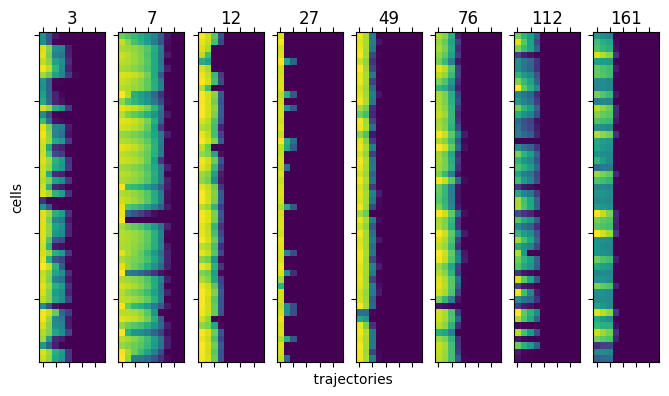

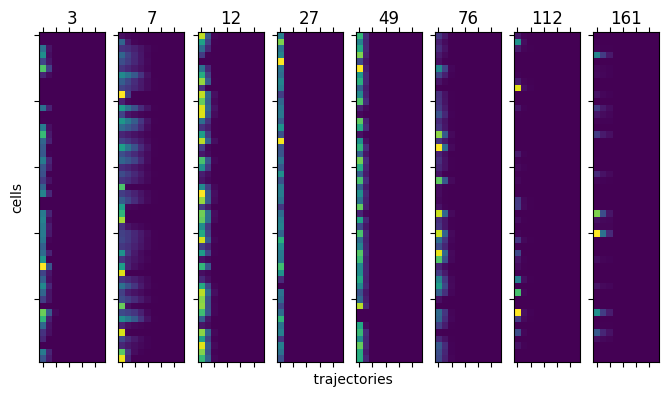

In [18]:
fig, axs = plt.subplots(1, 8, figsize=(8,8))

i = 0
for t, tmap in Tmaps.items():
    tmap = tmap.sum(axis=1)
    tmap_nz = tmap[tmap.sum(axis=1)!=0]

    axs[i].matshow(np.log(tmap_nz[:50]+1e-10))
    axs[i].set_title(t)
    axs[i].set_xticklabels('')
    axs[i].set_yticklabels('')

    i+=1

axs[0].set_ylabel('cells')
axs[3].set_xlabel("  "*10+'trajectories')


fig, axs = plt.subplots(1, 8, figsize=(8,8))

i = 0
for t, tmap in Tmaps.items():
    tmap = tmap.sum(axis=1)
    tmap_nz = tmap[tmap.sum(axis=1)!=0]

    axs[i].matshow(tmap_nz[:50])
    axs[i].set_title(t)
    axs[i].set_xticklabels('')
    axs[i].set_yticklabels('')
    i+=1

axs[0].set_ylabel('cells')
axs[3].set_xlabel("  "*10+'trajectories')


Text(0.5, 0, '                    trajectories')

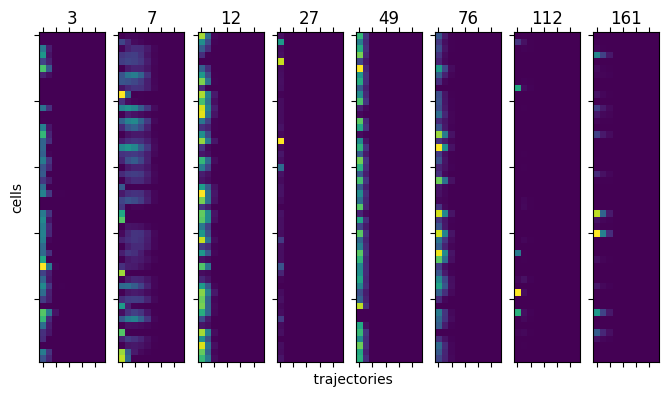

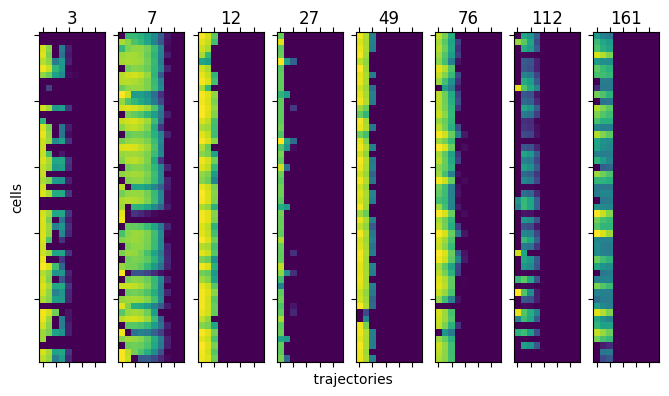

In [19]:
fig, axs = plt.subplots(1, 8, figsize=(8,8))

i = 0
for t, tmap in Tmaps.items():

    tmap_nz = tmap[tmap.sum(axis=1).sum(axis=1)!=0]

    axs[i].matshow(tmap_nz[:50,-1,:])
    axs[i].set_title(t)
    axs[i].set_xticklabels('')
    axs[i].set_yticklabels('')
    i+=1

axs[0].set_ylabel('cells')
axs[3].set_xlabel("  "*10+'trajectories')

fig, axs = plt.subplots(1, 8, figsize=(8,8))

i = 0
for t, tmap in Tmaps.items():

    tmap_nz = tmap[tmap.sum(axis=1).sum(axis=1)!=0]

    axs[i].matshow(np.log(tmap_nz[:50,-1,:]+1e-10))
    axs[i].set_title(t)
    axs[i].set_xticklabels('')
    axs[i].set_yticklabels('')
    i+=1

axs[0].set_ylabel('cells')
axs[3].set_xlabel("  "*10+'trajectories')

In [31]:
Tmaps_norm['3']

array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.48596092e-03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 1.34795370e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 4.52624292e-07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.60641158e-03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 2.72235028e-06, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 

Text(0.5, 1.0, '64')

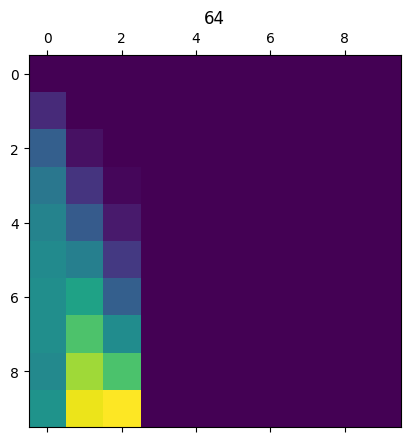

In [109]:
i = np.random.randint(0, 648)
# i = 383
plt.matshow(tmap_nz[i])
plt.title(i)

In [22]:
tmap_nz[i,0,0]

0.0

In [23]:
tmap_nz[i,1,0]

9.301001746564452e-09

In [24]:
tmap_nz[i,1,0]

9.301001746564452e-09

In [25]:
tmap_nz[i].sum()

2.47796013034228e-07

In [26]:
# np.save("results/tompos_Tmap/Tmap_by_u_ratio.npy", Tmaps)

# clustering

In [111]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

def hierarchical_clustering_sklearn(matrix, num_clusters, linkage='ward'):
    """
    Perform hierarchical clustering on the rows of a matrix using sklearn and return the clustered row indices.

    Parameters:
    - matrix: numpy array, the input matrix where rows are to be clustered.
    - num_clusters: int, the number of clusters to form (truncation level).
    - linkage: str, the linkage method to use (default is 'ward').

    Returns:
    - clustered_indices: list of lists, where each sublist contains the row indices of a cluster.
    """
    # Perform hierarchical clustering using AgglomerativeClustering
    clustering = AgglomerativeClustering(n_clusters=num_clusters, linkage=linkage)
    clusters = clustering.fit_predict(matrix)
    
    # Organize row indices by cluster
    clustered_indices = [[] for _ in range(num_clusters)]
    for row_index, cluster_id in enumerate(clusters):
        clustered_indices[cluster_id].append(row_index)
    
    return clustered_indices, clusters

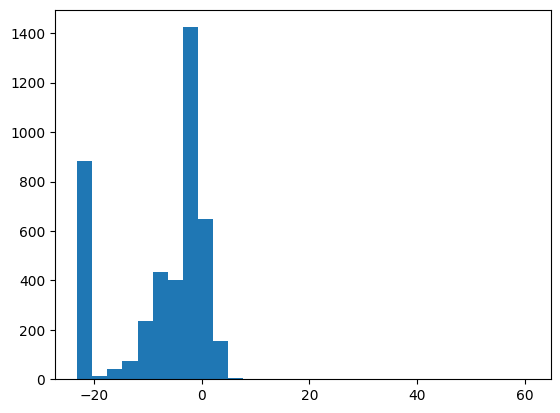

In [43]:
Tmap_all = np.concatenate(list(Tmaps.values()), axis=0)
plt.hist(np.log(Tmap_all[:,-1].sum(axis=1)+1e-10),bins=30);

In [76]:
Tmap_all_last = Tmap_all[:,-1,:]
Tmap_all_last
nz_id = np.where(Tmap_all_last.sum(axis=1)!=0)[0]
Tmap_all_last[nz_id] = Tmap_all_last[nz_id] / Tmap_all_last[nz_id].sum(axis=1,keepdims=True)

In [77]:
np.isnan(Tmap_all_last).sum()

0

In [78]:
# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(Tmap_all_last)

In [112]:
cluster_ids, cluster = hierarchical_clustering_sklearn(Tmap_all_last, 4)

In [115]:
np.unique(cluster)

array([0, 1, 2, 3])

In [ ]:
HSC_cbs

In [81]:
import seaborn as sns

In [89]:
Tmap_all_flat = Tmap_all.reshape(-1,100)
nz_id = np.where(Tmap_all_flat.sum(axis=1)!=0)[0]
Tmap_all_flat[nz_id] = Tmap_all_flat[nz_id] / Tmap_all_flat[nz_id].sum(axis=1,keepdims=True)

In [96]:
g2.dendrogram_row.reordered_ind

[26,
 13,
 27,
 63,
 8,
 57,
 97,
 11,
 76,
 120,
 136,
 1,
 134,
 10,
 49,
 123,
 111,
 122,
 109,
 121,
 91,
 98,
 89,
 0,
 43,
 164,
 2721,
 2904,
 3235,
 2491,
 3175,
 2990,
 3342,
 2893,
 2955,
 3226,
 3319,
 2611,
 3390,
 2983,
 3083,
 2914,
 323,
 373,
 396,
 115,
 1196,
 3091,
 2666,
 3006,
 427,
 721,
 873,
 2333,
 2808,
 73,
 771,
 2328,
 3253,
 3318,
 366,
 3050,
 1695,
 19,
 32,
 318,
 628,
 1016,
 92,
 137,
 67,
 1003,
 2034,
 4,
 1144,
 3082,
 3266,
 534,
 2054,
 118,
 922,
 3205,
 3151,
 3165,
 961,
 1110,
 567,
 1234,
 834,
 1062,
 2056,
 2105,
 1212,
 95,
 902,
 2041,
 2191,
 2752,
 228,
 3355,
 2544,
 2331,
 2285,
 2902,
 3162,
 3448,
 2348,
 2763,
 3316,
 2487,
 3195,
 161,
 828,
 3155,
 1078,
 105,
 791,
 314,
 2136,
 313,
 648,
 806,
 2321,
 734,
 3221,
 90,
 132,
 3021,
 3119,
 683,
 823,
 3182,
 645,
 798,
 720,
 3055,
 1175,
 1950,
 2806,
 3238,
 246,
 301,
 183,
 283,
 290,
 304,
 215,
 303,
 556,
 853,
 593,
 987,
 520,
 730,
 595,
 443,
 542,
 667,
 499,
 469

In [99]:
g2.dendrogram_row.dendrogram.keys()

dict_keys(['icoord', 'dcoord', 'ivl', 'leaves', 'color_list', 'leaves_color_list'])

In [100]:
g2.dendrogram_row.dendrogram['leaves_color_list']

['C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',
 'C0',

In [171]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def truncated_clustermap(matrix, num_clusters, truncate_mode="level", p=3, method='ward', cmap='viridis'):
    """
    Create a truncated clustermap with colored dendrogram and return cluster assignments and reordered indices.

    Parameters:
    - matrix: numpy array, the input matrix where rows are to be clustered.
    - num_clusters: int, the number of clusters to form.
    - truncate_mode: str, the truncation mode for the dendrogram (default is "level").
    - p: int, the truncation parameter (e.g., number of levels for "level" mode).
    - method: str, the linkage method to use (default is 'ward').
    - cmap: str, the colormap for the heatmap (default is 'viridis').

    Returns:
    - clusters: numpy array, cluster assignments for each row.
    - reordered_indices: numpy array, reordered row indices based on the dendrogram.
    """
    # Compute pairwise distances and linkage matrix
    row_distances = pdist(matrix, metric='euclidean')
    row_linkage = linkage(row_distances, method=method)
    
    # Form clusters
    clusters = fcluster(row_linkage, num_clusters, criterion='maxclust')
    
    # Create a truncated dendrogram to get reordered indices
    dnd = dendrogram(row_linkage, truncate_mode=truncate_mode, p=p, no_plot=True)
    reordered_indices = dnd['leaves']
    
    # Map cluster labels to colors
    cluster_colors = sns.color_palette("husl", num_clusters)  # Use a color palette
    row_colors = [cluster_colors[label - 1] for label in clusters]  # Map labels to colors
    
    # Create a clustermap with the reordered indices and row colors
    g = sns.clustermap(
        matrix,
        row_linkage=row_linkage,
        col_linkage=None,  # Only cluster rows
        col_cluster=False,
        cmap=cmap,
        row_colors=row_colors,  # Color rows by cluster
        dendrogram_ratio=(0.2, 0),  # Adjust dendrogram size
        figsize=(8, 8)
    )

    # Add a legend for the row colors
    legend_patches = [
        Patch(color=cluster_colors[i], label=f"Cluster {i + 1}")
        for i in range(num_clusters)
    ]
    plt.legend(
        handles=legend_patches,
        title="Clusters",
        bbox_to_anchor=(-0.5, -4),
        loc='lower left',
        borderaxespad=0.
    )


    plt.show()
    
    return clusters, reordered_indices

# Example usage:

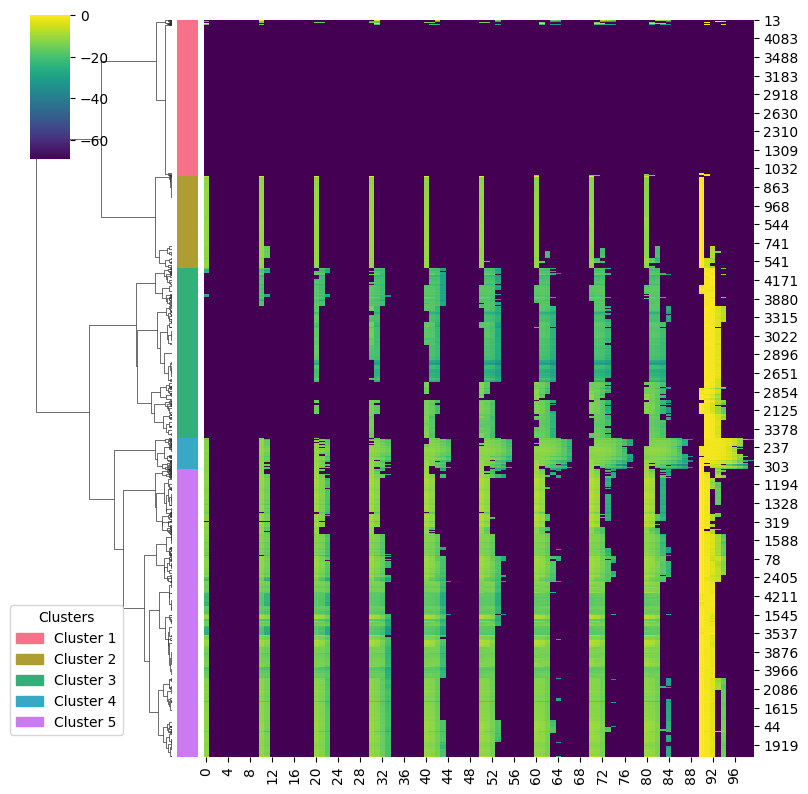

Cluster assignments: [1 1 5 ... 3 3 5]
Reordered row indices: [8562, 8582, 5185, 8549, 8339, 8425, 8569, 8600, 8603, 8611, 8621, 8631, 8597, 8622, 8627, 8633]


In [197]:
num_clusters = 5
cluster_flat, reordered_indices = truncated_clustermap(np.log(Tmap_all_flat+1e-30), num_clusters, truncate_mode="level", p=3)
print("Cluster assignments:", clusters)
print("Reordered row indices:", reordered_indices)

<Axes: title={'center': 'HSC_cluster_flat'}, xlabel='UMAP1', ylabel='UMAP2'>

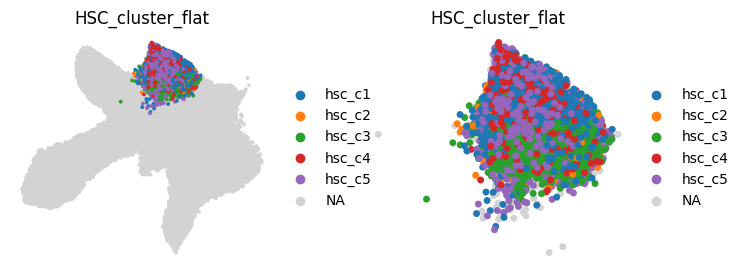

In [201]:
fig, axs = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35})
adata.obs['HSC_cluster_flat'] = 'na'
named_cluster_flats = ['hsc_c%s'%c for c in cluster_flat]
adata.obs.loc[np.concatenate(HSC_cbs), 'HSC_cluster_flat'] = named_cluster_flats
sc.pl.umap(adata, size=30,color='HSC_cluster_flat', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[0], frameon=False)
sc.pl.umap(adata[adata.obs.anno_man=='HSC'], size=100,color='HSC_cluster_flat', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[1], frameon=False)

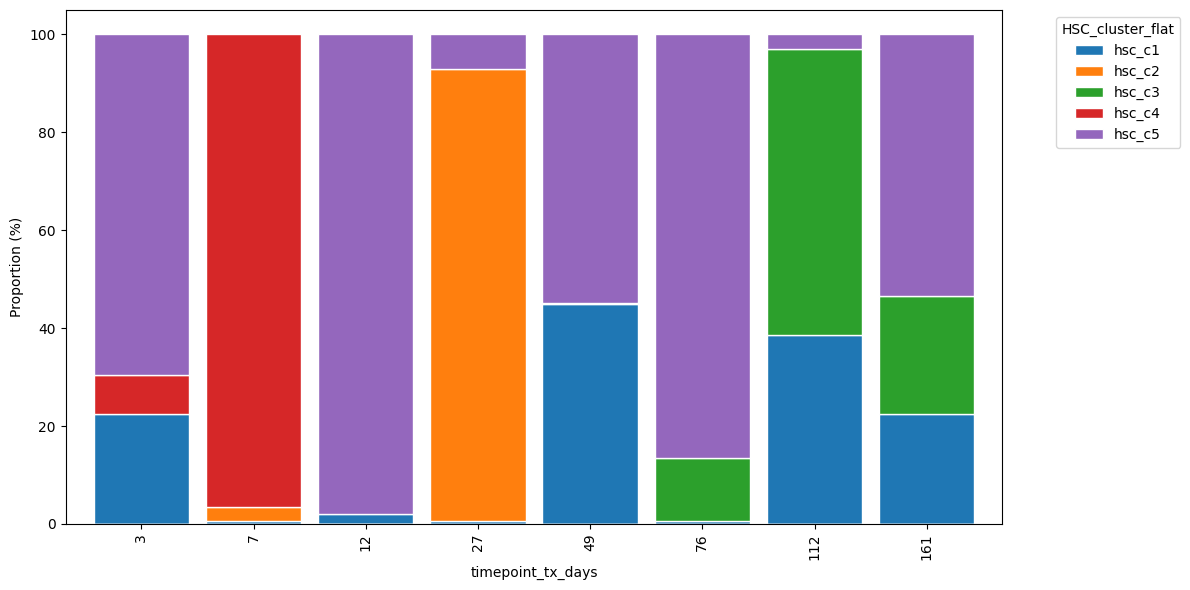

<Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>

In [206]:
dp.obs_composition(adata[np.concatenate(HSC_cbs)], 'timepoint_tx_days', 'HSC_cluster_flat')

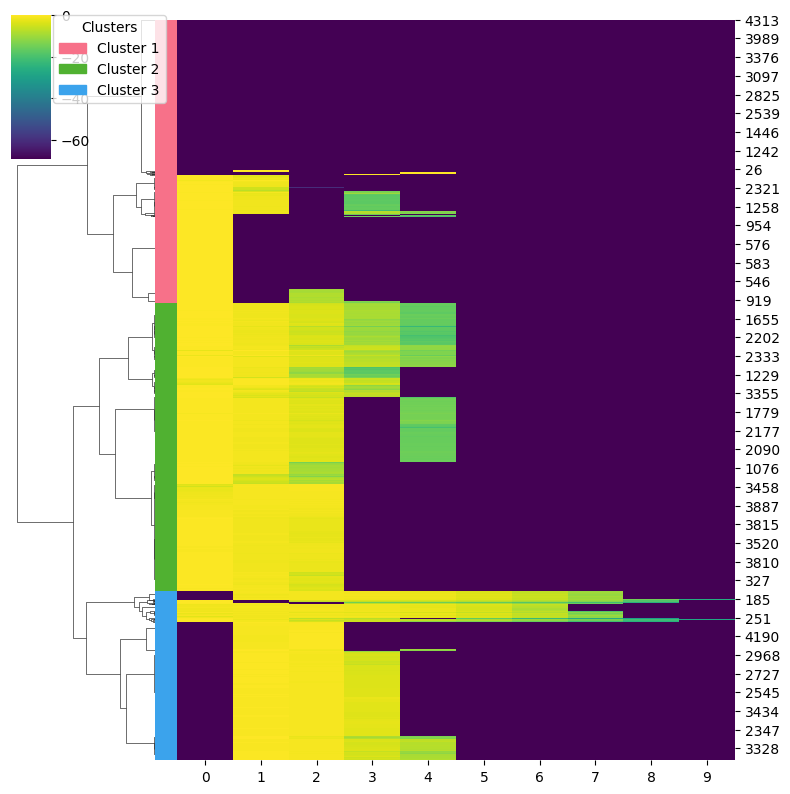

Cluster assignments: [1 1 1 ... 3 3 2]
Reordered row indices: [4313, 5198, 8613, 8618, 8586, 8625, 5660, 8617, 8600, 8606, 8582, 8608, 8616, 8627, 8620, 8632]


In [149]:
num_clusters = 3

clusters, reordered_indices = truncated_clustermap(np.log(Tmap_all_last+1e-30), num_clusters, truncate_mode="level", p=3)
print("Cluster assignments:", clusters)
print("Reordered row indices:", reordered_indices)

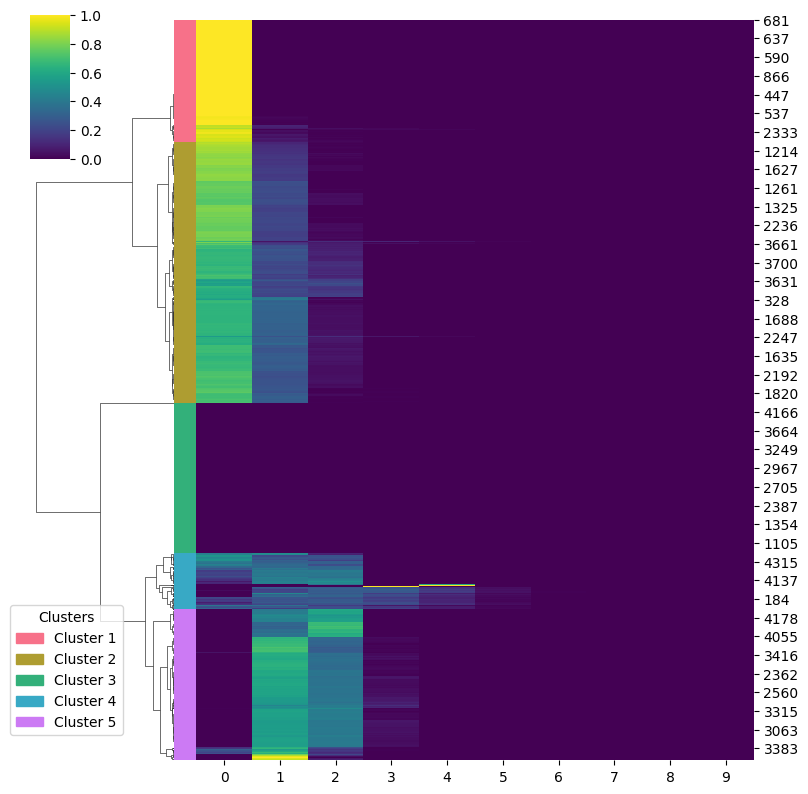

Cluster assignments: [3 4 2 ... 5 5 2]
Reordered row indices: [8144, 8423, 8559, 8572, 8605, 8611, 8623, 8624, 4313, 4312, 5197, 8630, 8633, 8622, 8632]


In [203]:
num_clusters = 5

clusters, reordered_indices = truncated_clustermap(Tmap_all_last, num_clusters, truncate_mode="level", p=3)
print("Cluster assignments:", clusters)
print("Reordered row indices:", reordered_indices)

<Axes: title={'center': 'HSC_sub_clusters'}, xlabel='UMAP1', ylabel='UMAP2'>

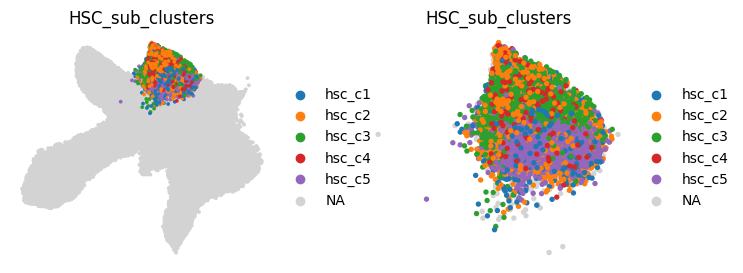

In [205]:
adata.obs['HSC_sub_clusters'] = 'na'
named_clusters = ['hsc_c%s'%c for c in clusters]
adata.obs.loc[np.concatenate(HSC_cbs), 'HSC_sub_clusters'] = named_clusters

fig, axs = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35})

sc.pl.umap(adata, size=30,color='HSC_sub_clusters', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[0], frameon=False)
sc.pl.umap(adata[adata.obs.anno_man=='HSC'], size=60,color='HSC_sub_clusters', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[1], frameon=False)

In [184]:
from PINN.plotting_fns import density_plot as dp

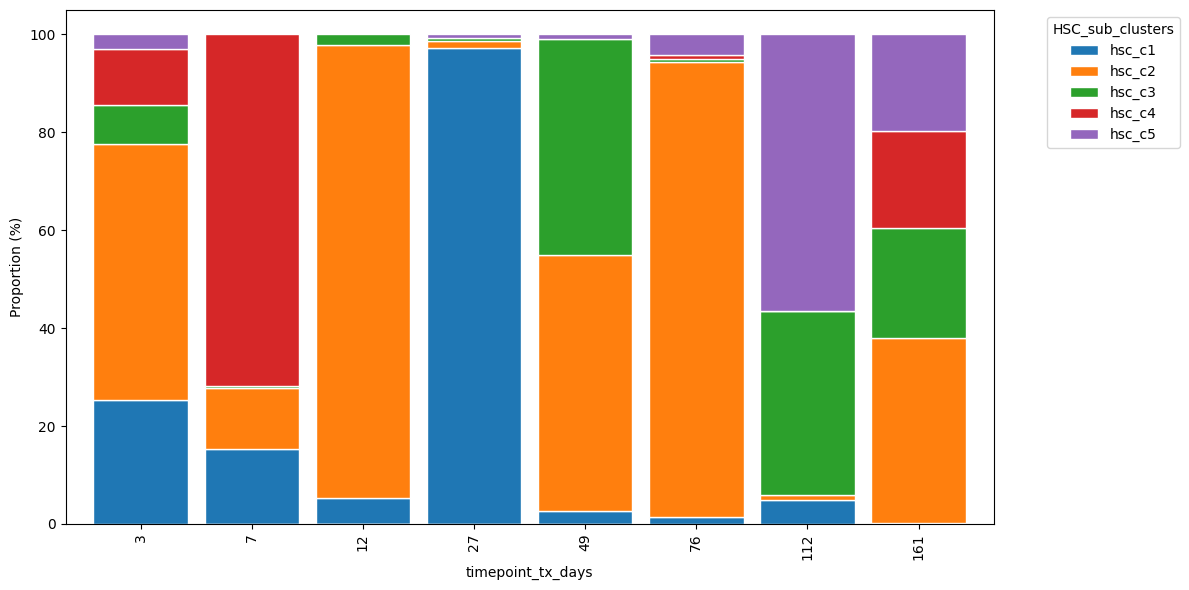

<Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>

In [187]:
dp.obs_composition(adata[np.concatenate(HSC_cbs)], 'timepoint_tx_days', 'HSC_sub_clusters')

In [ ]:
adata.obs.plot()

In [126]:
reordered_indices

[8144,
 8423,
 8559,
 8572,
 8605,
 8611,
 8623,
 8624,
 4313,
 4312,
 5197,
 8630,
 8633,
 8622,
 8632]